In [18]:
from PIL import Image
import numpy as np

def media_imagens(imagens):
    # Garantir que todas as imagens tenham as mesmas dimensões
    if not all(imagem.shape == imagens[0].shape for imagem in imagens):
        raise ValueError("Todas as imagens devem ter as mesmas dimensões.")
    
    # Calcular a média das imagens, mantendo os múltiplos canais
    media = np.mean(imagens, axis=0).astype(np.uint8)
    
    # Converter o array de volta para uma imagem
    if media.ndim == 3:  # Verifica se a imagem tem múltiplos canais
        imagem_media = Image.fromarray(media, mode='RGB')
    else:
        imagem_media = Image.fromarray(media)
    
    return imagem_media

In [ ]:
def calculate_avarage_of_images(imagens):
    """
    Calculate the average of a list of images, ensuring all images have the same dimensions and data type.

    Parameters:
    imagens (list of numpy.ndarray): List of images to be averaged. All images must have the same dimensions.

    Returns:
    numpy.ndarray: The averaged image with the same data type as the input images.

    Raises:
    ValueError: If the images do not have the same dimensions or if the data type is not supported.
    """
    # Ensure all images have the same dimensions
    if not all(imagem.shape == imagens[0].shape for imagem in imagens):
        raise ValueError("All images must have the same dimensions.")
    
    # Convert all images to float32 to avoid overflow issues during averaging
    imagens_float = [imagem.astype(np.float32) for imagem in imagens]
    
    # Calculate the average of the images
    media = np.mean(imagens_float, axis=0)
    
    # Convert the average back to the original data type of the images
    if imagens[0].dtype == np.uint8:
        media = media.astype(np.uint8)
    elif imagens[0].dtype == np.uint16:
        media = media.astype(np.uint16)
    else:
        raise ValueError("Unsupported data type.")
    
    return media


In [ ]:
def media_imagens(imagens):
    # Garantir que todas as imagens tenham as mesmas dimensões
    if not all(imagem.shape == imagens[0].shape for imagem in imagens):
        raise ValueError("Todas as imagens devem ter as mesmas dimensões.")
    
    # Calcular a média das imagens, mantendo os múltiplos canais
    media = np.mean(imagens, axis=0).astype(np.uint8)
    
    return media


In [ ]:
from common.io import find_all_files, read_images, save_image
import os
import matplotlib.pyplot as plt

input_path = '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50'

all_files_path = find_all_files(input_path)
zf_dir_name = sorted(set([os.path.basename(os.path.dirname(path)) for path in all_files_path if os.path.basename(os.path.dirname(path)).startswith('zf')]))

list_of_images = []
for zf in zf_dir_name:

    filtered_dir = sorted([i for i in all_files_path if f'{zf}' in i and 'sVal.png' in i])
    image_list = read_images(filtered_dir, info=False)
    #image_list = [(image / image.max() * 255).astype(np.uint8) for image in image_list]
    mean = calculate_avarage_of_images(image_list)
    save_image('/home/lelis/Documents/Projetos/hybrid-stereo-method/notebooks/multifocus_stereo',f'mean_{zf}.png', mean)


    #plt.imshow(mean)
    #plt.axis('off')  # Remove axes for better visualization
    #plt.show()


    


In [32]:
filtered_dir

['/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/stQ-melon14-amb0.00-glo0.50/0512x0384-hs01-kr10/L000/zf125.0000-df020.0000/sVal.png',
 '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/stQ-melon14-amb0.00-glo0.50/0512x0384-hs01-kr10/L001/zf125.0000-df020.0000/sVal.png',
 '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/stQ-melon14-amb0.00-glo0.50/0512x0384-hs01-kr10/L002/zf125.0000-df020.0000/sVal.png',
 '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/stQ-melon14-amb0.00-glo0.50/0512x0384-hs01-kr10/L003/zf125.0000-df020.0000/sVal.png',
 '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/stQ-melon14-amb0.00-glo0.50/0512x0384-hs01-kr10/L004/zf125.0000-df020.0000/s

In [35]:
image_list[1].shape

(422, 512, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].


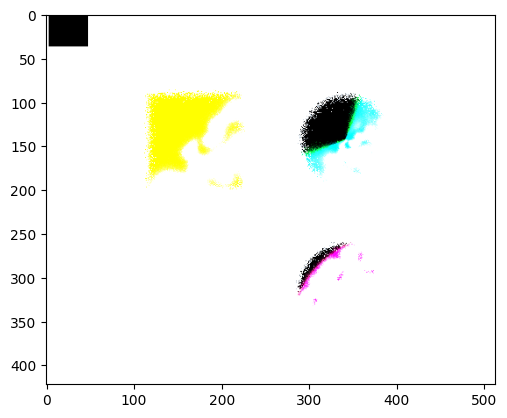

In [37]:
plt.imshow(image_list[0])